### Generate Websky 90 - 220 GHz Maps with noise or smoothing the maps

In [9]:
import time
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import importlib
from pixell import enmap, utils, reproject
from pixell.enmap import ndmap, fft, ifft
from maps import white_noise

from webskymaker import create_websky_map, generate_coords

path = "/mnt/welch/USERS/cwhitaker/maps/websky/"
#path = "/scratch/jorlo/websky/"

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
t0 = time.time()
webskyf090map = create_websky_map(path=path, freq="90")
t1 = time.time()
print(t1 - t0)

54.81050252914429


In [ ]:
coords = generate_coords()

In [5]:
websky090 = reproject.thumbnails(webskyf090map, coords[0], r = 2 * utils.degree)

In [6]:
def smooth_gauss(emap, sigma):
    """
    Smooth the map given as the first argument with a gaussian beam
    with the given standard deviation sigma in radians.
    """
    if np.all(sigma == 0): return emap.copy()
    f  = fft(emap)
    x2 = np.sum(emap.lmap()**2*sigma**2,0)
    if sigma >= 0: f *= np.exp(-0.5*x2)
    else:          f *= 1-np.exp(-0.5*x2)
    return enmap.enmap(ifft(f).real, emap.wcs)
def fwhm_to_sigma(fwhm):
    # Converts fwhm arcmins to sigma radians
    return fwhm / (2.*np.sqrt(2.*np.log(2.))) * (np.pi / (180.*60.))
    
print(fwhm_to_sigma(fwhm=2.2))
smoothweb = smooth_gauss(websky090, fwhm_to_sigma(2.2))

0.0002717634667731804


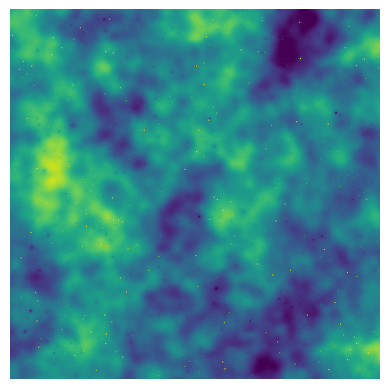

In [7]:
lims=300
plt.imshow(websky090, vmin=-lims, vmax=lims)
plt.axis(False);

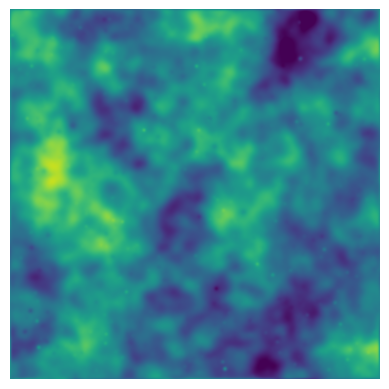

In [8]:
lims=300
plt.imshow(smoothweb, vmin=-lims, vmax=lims)
plt.axis(False);